# 🚀 Stage 1: Weak Supervision (Reddit Gaming)

**Mục tiêu:** Fine-tune RoBERTa sử dụng weak labels từ Reddit gaming signals

**Dataset:** Reddit Gaming Posts (6 subreddits)

**Method:** 8-signal weak supervision với weighted voting

---

## 📊 Pipeline:

1. **Data Collection:** Scrape Reddit gaming posts
2. **Weak Labeling:** 8-signal approach (awards, comments, ratio, score, text, sarcasm, flair, top comments)
3. **Model Training:** Fine-tune RoBERTa on weak labels
4. **Evaluation:** Calculate metrics like Stages 2-3
5. **Export:** Generate `stage1_results.json`

---

**⚠️ CHẠY TRÊN GOOGLE COLAB**  
Runtime → Change runtime type → T4 GPU

## 📦 Stage 0: Environment Setup

In [1]:
# Install required packages
!pip install -q praw prawcore
!pip install -q transformers torch
!pip install -q datasets scikit-learn
!pip install -q pandas numpy matplotlib seaborn
!pip install -q tqdm

print("✅ Packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 3.9 MB/s eta 0:00:00
✅ Packages installed successfully!


In [2]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('praw').setLevel(logging.ERROR)

import praw
import pandas as pd
import numpy as np
from datetime import datetime
import time
import re
from tqdm.auto import tqdm
import json

# Transformers & PyTorch
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🤖 GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Device: {torch.cuda.get_device_name(0)}")

✅ All imports successful!
🔥 PyTorch version: 2.9.0+cu126
🤖 GPU available: True
   Device: Tesla T4


## 🔐 Reddit API Configuration

In [3]:
# Reddit API Credentials
from getpass import getpass

print("📝 Nhập Reddit API credentials:")
print("   (Lấy từ: https://www.reddit.com/prefs/apps)")
print("   App type: 'personal use script'\n")

CLIENT_ID = input("Client ID: ").strip()
CLIENT_SECRET = getpass("Client Secret: ").strip()
USERNAME = input("Reddit Username: ").strip()

USER_AGENT = f"python:sentiment_analysis:v1.0 (by /u/{USERNAME})"

print("\n✅ Credentials saved!")
print(f"   User agent: {USER_AGENT}")

📝 Nhập Reddit API credentials:
   (Lấy từ: https://www.reddit.com/prefs/apps)
   App type: 'personal use script'

Client ID: VmsLltwOwxbbvUNP4ZTVzg
Client Secret: ··········
Reddit Username: Icy-Rutabaga7718

✅ Credentials saved!
   User agent: python:sentiment_analysis:v1.0 (by /u/Icy-Rutabaga7718)


## 📊 Stage 1: Reddit Gaming Data Collection

In [4]:
class GamingRedditScraper:
    def __init__(self, client_id, client_secret, user_agent):
        """Initialize Reddit API connection for gaming data collection"""
        self.reddit = praw.Reddit(
            client_id=client_id,
            client_secret=client_secret,
            user_agent=user_agent,
            check_for_async=False
        )

        try:
            test_sub = self.reddit.subreddit('gaming')
            print(f"✅ Connected to Reddit API")
            print(f"   Read-only: {self.reddit.read_only}")
            print(f"   Test subreddit: r/{test_sub.display_name}")
        except Exception as e:
            print(f"❌ Connection error: {e}")

    def scrape_gaming_posts(self, subreddit_name, keywords, limit=100, time_filter='month'):
        """Scrape gaming posts with full metadata for weak supervision"""
        all_posts = []
        subreddit = self.reddit.subreddit(subreddit_name)

        print(f"\n🎮 Scraping r/{subreddit_name}...")

        for keyword in keywords:
            print(f"   Searching '{keyword}'...", end=' ')

            try:
                search_results = subreddit.search(
                    keyword,
                    sort='relevance',
                    time_filter=time_filter,
                    limit=limit
                )

                count = 0
                for post in search_results:
                    try:
                        if post.selftext in ['[removed]', '[deleted]']:
                            continue

                        # Gaming-specific post data
                        post_data = {
                            'id': post.id,
                            'title': post.title,
                            'selftext': post.selftext,
                            'text': post.title + ' ' + post.selftext,
                            'url': post.url,
                            'created_utc': datetime.fromtimestamp(post.created_utc),

                            # Weak supervision signals
                            'score': post.score,
                            'upvote_ratio': post.upvote_ratio,
                            'num_comments': post.num_comments,
                            'num_awards': post.total_awards_received,

                            # Gaming metadata
                            'subreddit': subreddit_name,
                            'author': str(post.author),
                            'flair': post.link_flair_text,
                            'is_self': post.is_self,
                            'keyword': keyword,

                            # Top comments for context
                            'top_comments': self._get_top_comments(post, limit=3)
                        }

                        all_posts.append(post_data)
                        count += 1

                    except Exception as e:
                        continue

                print(f"✓ {count} posts")
                time.sleep(1)  # Rate limiting

            except Exception as e:
                print(f"✗ Error: {e}")
                continue

        return all_posts

    def _get_top_comments(self, post, limit=3):
        """Get top comments with gaming sentiment signals"""
        comments_data = []

        try:
            post.comments.replace_more(limit=0)
            top_comments = sorted(post.comments.list(),
                                key=lambda x: x.score,
                                reverse=True)[:limit]

            for comment in top_comments:
                try:
                    comments_data.append({
                        'body': comment.body,
                        'score': comment.score,
                        'has_sarcasm': '/s' in comment.body.lower(),
                        'awards': comment.total_awards_received
                    })
                except:
                    continue
        except:
            pass

        return comments_data

    def scrape_gaming_subreddits(self, subreddits, keywords, limit_per_subreddit=50):
        """Scrape from multiple gaming subreddits"""
        all_data = []

        for subreddit in subreddits:
            posts = self.scrape_gaming_posts(subreddit, keywords, limit_per_subreddit)
            all_data.extend(posts)

        return all_data

print("✅ GamingRedditScraper class defined!")

✅ GamingRedditScraper class defined!


In [5]:
# Initialize gaming scraper
scraper = GamingRedditScraper(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

✅ Connected to Reddit API
   Read-only: True
   Test subreddit: r/gaming


In [6]:
# Gaming-focused configuration
GAMING_SUBREDDITS = [
    'gaming',
    'Games',
    'pcgaming',
    'gamernews',
    'gamedev',
    'indiegaming'
]

GAMING_KEYWORDS = [
    'game',
    'gaming',
    'gameplay',
    'review',
    'experience',
    'bug',
    'issue',
    'performance',
    'story',
    'fun'
]

# GPU-based data size optimization (INCREASED for better quality)
if torch.cuda.is_available():
    POSTS_PER_SUBREDDIT = 800  # Increased from 100 to 500 for richer dataset
    estimated_time = "30-60 phút cho training"
else:
    POSTS_PER_SUBREDDIT = 50   # Increased from 20 to 50 for CPU users
    estimated_time = "10-20 phút (khuyến nghị BẬT GPU!)"

print("📋 Gaming Data Configuration:")
print(f"   GPU detected: {'✅ Yes' if torch.cuda.is_available() else '❌ No (SLOW!)'}")
print(f"   Gaming subreddits: {len(GAMING_SUBREDDITS)}")
print(f"   Gaming keywords: {len(GAMING_KEYWORDS)}")
print(f"   Posts per subreddit: {POSTS_PER_SUBREDDIT}")
print(f"   Target posts: ~{len(GAMING_SUBREDDITS) * POSTS_PER_SUBREDDIT} (max)")
print(f"   Estimated time: {estimated_time}")

📋 Gaming Data Configuration:
   GPU detected: ✅ Yes
   Gaming subreddits: 6
   Gaming keywords: 10
   Posts per subreddit: 800
   Target posts: ~4800 (max)
   Estimated time: 30-60 phút cho training


In [7]:
# Start gaming data collection!
print("🎮 Starting gaming data collection...")
print("⏰ This may take 10-20 minutes...\n")

gaming_data = scraper.scrape_gaming_subreddits(
    subreddits=GAMING_SUBREDDITS,
    keywords=GAMING_KEYWORDS,
    limit_per_subreddit=POSTS_PER_SUBREDDIT
)

print(f"\n🎉 Gaming data collection complete!")
print(f"   Total gaming posts collected: {len(gaming_data)}")

🎮 Starting gaming data collection...
⏰ This may take 10-20 minutes...


🎮 Scraping r/gaming...
   Searching 'game'... ✓ 249 posts
   Searching 'gaming'... ✓ 250 posts
   Searching 'gameplay'... ✓ 69 posts
   Searching 'review'... ✓ 27 posts
   Searching 'experience'... ✓ 57 posts
   Searching 'bug'... ✓ 23 posts
   Searching 'issue'... ✓ 47 posts
   Searching 'performance'... ✓ 30 posts
   Searching 'story'... ✓ 73 posts
   Searching 'fun'... ✓ 106 posts

🎮 Scraping r/Games...
   Searching 'game'... ✓ 250 posts
   Searching 'gaming'... ✓ 250 posts
   Searching 'gameplay'... ✓ 131 posts
   Searching 'review'... ✓ 61 posts
   Searching 'experience'... ✓ 98 posts
   Searching 'bug'... ✓ 15 posts
   Searching 'issue'... ✓ 18 posts
   Searching 'performance'... ✓ 29 posts
   Searching 'story'... ✓ 88 posts
   Searching 'fun'... ✓ 83 posts

🎮 Scraping r/pcgaming...
   Searching 'game'... ✓ 249 posts
   Searching 'gaming'... ✓ 249 posts
   Searching 'gameplay'... ✓ 52 posts
   Searching 'revi

In [8]:
# Convert to DataFrame
df_raw = pd.DataFrame(gaming_data)

print("📊 Gaming Dataset Info:")
print(f"   Shape: {df_raw.shape}")
print(f"   Columns: {df_raw.columns.tolist()}")
print(f"\n📈 Score statistics:")
print(df_raw['score'].describe())

# Display sample
print("\n🎮 Sample gaming posts:")
display(df_raw[['title', 'score', 'upvote_ratio', 'num_awards', 'subreddit']].head())

📊 Gaming Dataset Info:
   Shape: (5890, 16)
   Columns: ['id', 'title', 'selftext', 'text', 'url', 'created_utc', 'score', 'upvote_ratio', 'num_comments', 'num_awards', 'subreddit', 'author', 'flair', 'is_self', 'keyword', 'top_comments']

📈 Score statistics:
count     5890.000000
mean       468.928862
std       1853.100631
min          0.000000
25%          1.000000
50%         12.500000
75%        156.000000
max      35912.000000
Name: score, dtype: float64

🎮 Sample gaming posts:


,title,score,upvote_ratio,num_awards,subreddit
0,"After 5 years and a ton of work, my nostalgic ...",19509,0.98,0,gaming
1,Gabe Newell caps off Steam Machine week by tak...,13572,0.94,0,gaming
2,Highest-Selling Video Games Of All Time,16773,0.95,0,gaming
3,"""3"" pieces of Valve hardware announced...a wee...",25180,0.98,0,gaming
4,72% of devs believe Steam has a monopoly on PC...,9758,0.91,0,gaming


## 🏷️ Stage 2: Optimized Weak Label Generation

**NEW: 8-Signal Approach for Gaming Domain:**
1. **Awards** (weight: 4.0) - Strongest positive signal
2. **Comments** (weight: 3.0) - Community engagement
3. **Upvote Ratio** (weight: 2.5) - Community agreement  
4. **Post Score** (weight: 2.0) - Overall popularity
5. **Gaming Text Features** (weight: 1.8-3.0) - Dynamic gaming-specific analysis
6. **Sarcasm Detection** - Flips sentiment with /s tags
7. **Flair Analysis** (weight: 2.0-3.5) - Post category indicators **NEW!**
8. **Top Comments** (weight: 2.0-2.5) - Community response sentiment **NEW!**

**Enhanced Optimizations:**
- Weighted voting based on signal reliability
- Confidence scoring for quality control
- Gaming-specific vocabulary with N-grams
- Dynamic weighting (1.8-3.0) based on signal strength
- Strong indicator patterns (3.0 weight)
- Balanced neutral zone

In [9]:
class OptimizedWeakLabelGenerator:
    """
    🎯 ENHANCED Weak Label Generator for Gaming Content

    Signals (ordered by reliability):
    1. Awards (4.0) - Premium positive signal
    2. Comment engagement (3.0) - Community interest
    3. Upvote ratio (2.5) - Community consensus
    4. Post score (2.0) - General popularity
    5. Gaming text features (1.8-3.0) - Dynamic weight based on strength
    6. Sarcasm detection (flip) - Sentiment reversal
    7. Flair analysis (3.5) - NEW: Post flair sentiment indicators
    8. Top comments analysis (2.5) - NEW: Community response sentiment

    ✅ Enhanced with 8 signals + dynamic weighting
    """

    def __init__(self):
        self.label_stats = {'positive': 0, 'negative': 0, 'neutral': 0}

        # Enhanced gaming vocabulary with stronger indicators
        self.gaming_positive_words = [
            'amazing', 'awesome', 'fantastic', 'incredible', 'masterpiece',
            'brilliant', 'excellent', 'perfect', 'love', 'favorite',
            'addictive', 'fun', 'enjoyable', 'satisfying', 'immersive',
            # NEW: Gaming-specific positives
            'goty', 'game of the year', 'must-play', 'well-optimized',
            'worth the price', 'highly recommend', 'polished', 'stunning'
        ]

        self.gaming_negative_words = [
            'terrible', 'horrible', 'awful', 'broken', 'buggy',
            'disappointing', 'boring', 'frustrating', 'waste', 'garbage',
            'unplayable', 'crash', 'glitch', 'repetitive', 'overpriced',
            # NEW: Gaming-specific negatives
            'pay-to-win', 'p2w', 'grindy', 'unoptimized', 'broken mess',
            'cash grab', 'waste of money', 'refunded', 'avoid this'
        ]

        # NEW: N-gram patterns (2-3 word phrases)
        self.positive_ngrams = [
            'worth the price', 'highly recommend', 'must play', 'well made',
            'great experience', 'love this game', 'amazing graphics', 'solid gameplay'
        ]

        self.negative_ngrams = [
            'waste of money', 'broken mess', 'cash grab', 'avoid this',
            'not worth it', 'total disappointment', 'buggy mess', 'poor optimization'
        ]

        # NEW: Strong indicators (higher weight)
        self.strong_positive = ['masterpiece', 'goty', 'game of the year', 'incredible']
        self.strong_negative = ['unplayable', 'broken mess', 'cash grab', 'waste of money']

    def extract_gaming_text_features(self, text):
        """Enhanced gaming-specific sentiment signals with dynamic weighting"""
        if pd.isna(text) or len(str(text).strip()) == 0:
            return None, 0

        text_original = str(text)
        text = text_original.lower()

        # Enhanced vocabulary analysis
        positive_matches = sum(1 for word in self.gaming_positive_words if word in text)
        negative_matches = sum(1 for word in self.gaming_negative_words if word in text)

        # NEW: Strong indicator analysis (higher weight)
        strong_positive_matches = sum(1 for word in self.strong_positive if word in text)
        strong_negative_matches = sum(1 for word in self.strong_negative if word in text)

        # NEW: N-gram analysis
        positive_ngram_matches = sum(1 for phrase in self.positive_ngrams if phrase in text)
        negative_ngram_matches = sum(1 for phrase in self.negative_ngrams if phrase in text)

        # Text characteristics
        caps_ratio = sum(1 for c in text_original if c.isupper()) / max(len(text_original), 1)
        exclamation_count = text.count('!')
        word_count = len(text.split())

        # ENHANCED: Dynamic weighting based on signal strength
        base_weight = 1.8

        # Check for strong indicators first (highest weight)
        if strong_positive_matches >= 1:
            return 'positive', 3.0  # Strong positive = high weight
        elif strong_negative_matches >= 1:
            return 'negative', 3.0  # Strong negative = high weight

        # Check for N-gram patterns (medium-high weight)
        elif positive_ngram_matches >= 1:
            return 'positive', 2.5
        elif negative_ngram_matches >= 1:
            return 'negative', 2.5

        # Multiple vocabulary matches (medium weight)
        elif positive_matches >= 2:
            return 'positive', 2.2
        elif negative_matches >= 2:
            return 'negative', 2.2  # Increased weight for multiple negatives
        elif positive_matches > negative_matches:
            return 'positive', 1.8  # Increased base weight
        elif negative_matches > positive_matches:
            return 'negative', 1.8  # Increased base weight
        elif caps_ratio > 0.3 and exclamation_count > 2:
            return 'negative', 1.5  # Gaming rant (increased weight)
        elif exclamation_count >= 3:
            return 'positive', 1.2  # Excited gaming (increased weight)
        elif word_count < 5:
            return 'neutral', 0.8  # Too short

        return None, 0

    def analyze_flair(self, flair):
        """NEW: Signal 7 - Analyze post flair for sentiment indicators"""
        if pd.isna(flair) or not flair:
            return None, 0

        flair_lower = str(flair).lower()

        # Negative flair patterns
        negative_flairs = ['rant', 'complaint', 'bug', 'issue', 'problem', 'broken', 'fix']
        if any(pattern in flair_lower for pattern in negative_flairs):
            return 'negative', 3.5  # High weight - flair is very reliable

        # Neutral/discussion flairs
        neutral_flairs = ['discussion', 'question', 'help', 'advice', 'opinion']
        if any(pattern in flair_lower for pattern in neutral_flairs):
            return 'neutral', 2.0  # Medium weight

        # Positive flair patterns
        positive_flairs = ['review', 'impressions', 'recommendation', 'praise', 'appreciation']
        if any(pattern in flair_lower for pattern in positive_flairs):
            return 'positive', 2.5  # Medium-high weight

        return None, 0

    def analyze_top_comments(self, top_comments):
        """NEW: Signal 8 - Analyze community response through top comments"""
        if not top_comments or len(top_comments) == 0:
            return None, 0

        comment_sentiments = []
        total_score = 0

        for comment in top_comments:
            try:
                body = str(comment.get('body', '')).lower()
                score = comment.get('score', 0)
                total_score += score

                if not body or len(body) < 10:
                    continue

                # Analyze comment sentiment
                positive_matches = sum(1 for word in self.gaming_positive_words if word in body)
                negative_matches = sum(1 for word in self.gaming_negative_words if word in body)

                # Strong agreement/disagreement indicators
                if score > 50:  # Highly upvoted comment
                    if positive_matches > negative_matches:
                        comment_sentiments.append('positive')
                    elif negative_matches > positive_matches:
                        comment_sentiments.append('negative')
                    else:
                        comment_sentiments.append('neutral')
                elif score > 10:  # Moderately upvoted
                    if positive_matches >= 2:
                        comment_sentiments.append('positive')
                    elif negative_matches >= 2:
                        comment_sentiments.append('negative')
                    else:
                        comment_sentiments.append('neutral')

            except Exception as e:
                continue

        if not comment_sentiments:
            return None, 0

        # Analyze community consensus
        positive_count = comment_sentiments.count('positive')
        negative_count = comment_sentiments.count('negative')
        neutral_count = comment_sentiments.count('neutral')

        # Strong community consensus
        if positive_count >= 2 and positive_count > negative_count:
            return 'positive', 2.5
        elif negative_count >= 2 and negative_count > positive_count:
            return 'negative', 2.5
        elif neutral_count >= 2 or (positive_count == negative_count):
            return 'neutral', 2.0

        return None, 0

    def detect_sarcasm(self, text):
        """Enhanced sarcasm detection for gaming content"""
        text_lower = str(text).lower()

        # Strong sarcasm markers
        if '/s' in text_lower or ' /s' in text_lower:
            return True

        # Gaming-specific sarcasm patterns
        sarcasm_patterns = [
            'yeah right', 'sure thing', 'totally', 'obviously',
            'clearly', 'definitely', 'absolutely', 'perfectly balanced'
        ]

        for pattern in sarcasm_patterns:
            if pattern in text_lower:
                # Need negative context for non-/s markers
                if any(neg in text_lower for neg in ['not', 'never', 'cant', "can't", 'broken']):
                    return True

        return False

    def generate_optimized_weak_label(self, row):
        """Generate weak label with optimized gaming-focused signals"""
        signals = []
        weights = []

        score = row['score']
        ratio = row['upvote_ratio']
        awards = row.get('num_awards', 0)
        num_comments = row.get('num_comments', 0)
        # Handle both 'text' and 'title' fields
        text = str(row.get('text', row.get('title', '')))

        # ========================================
        # Signal 1: Awards (WEIGHT: 4.0 - STRONGEST)
        # ========================================
        if awards >= 5:  # Multiple awards = very positive
            signals.append('positive')
            weights.append(4.0)
        elif awards >= 2:  # Some awards = positive
            signals.append('positive')
            weights.append(3.5)
        elif awards >= 1:  # Single award = likely positive
            signals.append('positive')
            weights.append(3.0)

        # ========================================
        # Signal 2: Comment Engagement (WEIGHT: 3.0)
        # ========================================
        if num_comments > 200:  # High engagement
            signals.append('positive')
            weights.append(3.0)
        elif num_comments > 100:  # Good engagement
            signals.append('positive')
            weights.append(2.5)
        elif num_comments > 50:  # Moderate engagement
            signals.append('neutral')
            weights.append(2.0)
        elif num_comments > 20:  # Some engagement
            signals.append('neutral')
            weights.append(1.5)
        elif num_comments < 3 and score > 0:  # Low engagement
            signals.append('neutral')
            weights.append(1.0)

        # ========================================
        # Signal 3: Upvote Ratio (WEIGHT: 2.5)
        # ========================================
        if ratio >= 0.95:  # Overwhelming agreement
            signals.append('positive')
            weights.append(2.5)
        elif ratio >= 0.85:  # Strong agreement
            signals.append('positive')
            weights.append(2.2)
        elif ratio >= 0.75:  # Good agreement
            signals.append('positive')
            weights.append(1.8)
        elif 0.55 <= ratio <= 0.70:  # Controversial/neutral zone
            signals.append('neutral')
            weights.append(2.0)
        elif ratio < 0.45:  # Strong disagreement
            signals.append('negative')
            weights.append(2.5)
        elif ratio < 0.55:  # Mild disagreement
            signals.append('negative')
            weights.append(2.0)

        # ========================================
        # Signal 4: Post Score (WEIGHT: 2.0)
        # ========================================
        if score > 500:  # Viral positive
            signals.append('positive')
            weights.append(2.0)
        elif score > 100:  # Popular positive
            signals.append('positive')
            weights.append(1.8)
        elif score > 50:  # Moderately positive
            signals.append('positive')
            weights.append(1.5)
        elif score > 10:  # Slightly positive
            signals.append('neutral')
            weights.append(1.2)
        elif 0 <= score <= 10:  # Neutral zone
            signals.append('neutral')
            weights.append(1.8)  # Higher weight for neutral
        elif score < -10:  # Strongly negative
            signals.append('negative')
            weights.append(2.0)
        elif score < 0:  # Mildly negative
            signals.append('negative')
            weights.append(1.5)

        # ========================================
        # Signal 5: Gaming Text Features (WEIGHT: 1.8-3.0)
        # ========================================
        text_signal, text_weight = self.extract_gaming_text_features(text)
        if text_signal:
            signals.append(text_signal)
            weights.append(text_weight)

        # ========================================
        # Signal 6: Sarcasm Detection (FLIP)
        # ========================================
        has_sarcasm = self.detect_sarcasm(text)

        if has_sarcasm:
            # Flip positive ↔ negative, keep neutral
            signals = [
                'negative' if s == 'positive' else
                'positive' if s == 'negative' else
                'neutral'
                for s in signals
            ]

        # ========================================
        # Signal 7: Flair Analysis (WEIGHT: 2.0-3.5) - NEW!
        # ========================================
        flair_signal, flair_weight = self.analyze_flair(row.get('link_flair_text'))
        if flair_signal:
            signals.append(flair_signal)
            weights.append(flair_weight)

        # ========================================
        # Signal 8: Top Comments Analysis (WEIGHT: 2.0-2.5) - NEW!
        # ========================================
        if hasattr(row, 'top_comments') and row.get('top_comments'):
            comments_signal, comments_weight = self.analyze_top_comments(row.get('top_comments'))
            if comments_signal:
                signals.append(comments_signal)
                weights.append(comments_weight)

        # ========================================
        # Weighted Voting
        # ========================================
        if not signals:
            return None, 0.0

        label_votes = {}
        for signal, weight in zip(signals, weights):
            label_votes[signal] = label_votes.get(signal, 0) + weight

        final_label = max(label_votes, key=label_votes.get)
        total_weight = sum(weights)
        confidence = label_votes[final_label] / total_weight

        return final_label, confidence

    def apply_weak_labels(self, df, min_confidence=0.6):
        """Apply optimized weak labeling to gaming dataset"""
        weak_labels = []
        confidences = []

        for idx, row in tqdm(df.iterrows(), total=len(df), desc="🎮 Generating gaming weak labels"):
            label, conf = self.generate_optimized_weak_label(row)

            if label and conf >= min_confidence:
                weak_labels.append(label)
                confidences.append(conf)
                self.label_stats[label] += 1
            else:
                weak_labels.append(None)
                confidences.append(0.0)
                self.label_stats['skipped'] = self.label_stats.get('skipped', 0) + 1

        df['weak_label'] = weak_labels
        df['weak_confidence'] = confidences

        return df

    def balance_classes(self, df):
        """Smart class balancing for gaming data"""
        df_labeled = df[df['weak_label'].notna()].copy()

        class_counts = df_labeled['weak_label'].value_counts()
        print(f"\n📊 Before balancing:")
        print(class_counts)

        min_class_count = class_counts.min()
        target_size = int(min_class_count * 1.5)
        #target_size = max(int(class_counts.median()), 100)

        balanced_dfs = []
        for label in ['positive', 'negative', 'neutral']:
            class_df = df_labeled[df_labeled['weak_label'] == label]

            if len(class_df) > target_size:
                # Keep highest confidence samples
                class_df = class_df.nlargest(target_size, 'weak_confidence')

            balanced_dfs.append(class_df)

        df_balanced = pd.concat(balanced_dfs, ignore_index=True)

        print(f"\n📊 After balancing:")
        print(df_balanced['weak_label'].value_counts())
        print(f"\n✅ Average confidence: {df_balanced['weak_confidence'].mean():.3f}")

        return df_balanced

print("✅ OptimizedWeakLabelGenerator defined!")
print("   🎮 Gaming-optimized with 8 signals")
print("   ⚖️ Weighted voting + confidence scoring")
print("   🎯 Enhanced neutral zone support")

✅ OptimizedWeakLabelGenerator defined!
   🎮 Gaming-optimized with 8 signals
   ⚖️ Weighted voting + confidence scoring
   🎯 Enhanced neutral zone support


In [10]:
# 🎮 TEST ENHANCED WEAK LABEL GENERATOR
print("🧪 Testing Enhanced 8-Signal Weak Label Generator...")

# Test sample with gaming data
test_sample = {
    'title': 'This game is absolutely amazing! The graphics are incredible and gameplay is super smooth',
    'score': 1500,
    'upvote_ratio': 0.95,
    'num_awards': 5,
    'num_comments': 250,
    'link_flair_text': 'Review',
    'top_comments': [
        {'body': 'totally agree! best game ever', 'score': 45},
        {'body': 'graphics are mindblowing', 'score': 32},
        {'body': 'gameplay feels so polished', 'score': 28}
    ]
}

# Test the enhanced generator
weak_labeler = OptimizedWeakLabelGenerator()
result_label, result_confidence = weak_labeler.generate_optimized_weak_label(pd.Series(test_sample))

print(f"\n🎯 Test Results:")
print(f"   Sample: {test_sample['title'][:50]}...")
print(f"   Predicted Label: {result_label}")
print(f"   Confidence: {result_confidence:.3f}")

# Test individual signals
print(f"\n🔍 Signal Analysis:")
print(f"   1. Awards: {test_sample['num_awards']} → HIGH positive weight")
print(f"   2. Comments: {test_sample['num_comments']} → HIGH engagement")
print(f"   3. Upvote Ratio: {test_sample['upvote_ratio']} → positive")
print(f"   4. Score: {test_sample['score']} → positive")
print(f"   5. Text Features: Enhanced gaming vocabulary detection")
print(f"   6. Sarcasm: No /s detected")
print(f"   7. Flair: '{test_sample['link_flair_text']}' → positive review flair")
print(f"   8. Top Comments: Community sentiment analysis")

print(f"\n✅ Enhanced 8-signal system working correctly!")
print(f"   - Dynamic weighting (1.8-3.5 range)")
print(f"   - Gaming-specific vocabulary")
print(f"   - Flair & Comments analysis")

🧪 Testing Enhanced 8-Signal Weak Label Generator...

🎯 Test Results:
   Sample: This game is absolutely amazing! The graphics are ...
   Predicted Label: positive
   Confidence: 0.895

🔍 Signal Analysis:
   1. Awards: 5 → HIGH positive weight
   2. Comments: 250 → HIGH engagement
   3. Upvote Ratio: 0.95 → positive
   4. Score: 1500 → positive
   5. Text Features: Enhanced gaming vocabulary detection
   6. Sarcasm: No /s detected
   7. Flair: 'Review' → positive review flair
   8. Top Comments: Community sentiment analysis

✅ Enhanced 8-signal system working correctly!
   - Dynamic weighting (1.8-3.5 range)
   - Gaming-specific vocabulary
   - Flair & Comments analysis


In [11]:
# 🏷️ APPLY ENHANCED WEAK LABELING TO GAMING DATASET
print("🎮 Applying enhanced 8-signal weak labeling to gaming dataset...")
print(f"   Dataset size: {len(df_raw)} posts")
print(f"   Enhanced signals: Awards, Comments, Upvote Ratio, Score, Gaming Text, Sarcasm, Flair, Top Comments")

# Apply weak labeling with enhanced system
weak_labeler = OptimizedWeakLabelGenerator()
df_weak_labeled = weak_labeler.apply_weak_labels(df_raw, min_confidence=0.6)

# Show enhanced statistics
print(f"\n📊 Enhanced Weak Labeling Results:")
labeled_count = len(df_weak_labeled[df_weak_labeled['weak_label'].notna()])
print(f"   Successfully labeled: {labeled_count}/{len(df_weak_labeled)} ({labeled_count/len(df_weak_labeled)*100:.1f}%)")

# Label distribution
label_dist = df_weak_labeled['weak_label'].value_counts()
print(f"\n🏷️ Label Distribution:")
for label, count in label_dist.items():
    if pd.notna(label):
        avg_conf = df_weak_labeled[df_weak_labeled['weak_label'] == label]['weak_confidence'].mean()
        print(f"   {label}: {count} posts (avg confidence: {avg_conf:.3f})")

# Show enhanced confidence distribution
print(f"\n📈 Confidence Distribution:")
print(f"   Mean confidence: {df_weak_labeled['weak_confidence'].mean():.3f}")
print(f"   Std confidence: {df_weak_labeled['weak_confidence'].std():.3f}")
print(f"   High confidence (>0.8): {len(df_weak_labeled[df_weak_labeled['weak_confidence'] > 0.8])}")

# Show sample high-confidence predictions
print(f"\n🎯 Sample High-Confidence Predictions:")
high_conf_samples = df_weak_labeled[df_weak_labeled['weak_confidence'] > 0.8].head(3)
for idx, row in high_conf_samples.iterrows():
    print(f"   {row['weak_label'].upper()}: '{row['title'][:60]}...' (conf: {row['weak_confidence']:.3f})")

print(f"\n✅ Enhanced weak labeling complete with 8-signal approach!")

🎮 Applying enhanced 8-signal weak labeling to gaming dataset...
   Dataset size: 5890 posts
   Enhanced signals: Awards, Comments, Upvote Ratio, Score, Gaming Text, Sarcasm, Flair, Top Comments


🎮 Generating gaming weak labels:   0%|          | 0/5890 [00:00<?, ?it/s]


📊 Enhanced Weak Labeling Results:
   Successfully labeled: 3659/5890 (62.1%)

🏷️ Label Distribution:
   positive: 1560 posts (avg confidence: 0.754)
   neutral: 1348 posts (avg confidence: 0.761)
   negative: 751 posts (avg confidence: 0.732)

📈 Confidence Distribution:
   Mean confidence: 0.467
   Std confidence: 0.378
   High confidence (>0.8): 821

🎯 Sample High-Confidence Predictions:
   POSITIVE: 'We often talk about Ludonarrative Dissonance and egregious e...' (conf: 1.000)
   POSITIVE: 'Both of these games devs have similar stories, made from Ex-...' (conf: 0.836)
   POSITIVE: 'Dispatch, the acclaimed superhero workplace comedy from a gr...' (conf: 1.000)

✅ Enhanced weak labeling complete with 8-signal approach!


In [12]:
# ⚖️ ENHANCED CLASS BALANCING
print("⚖️ Balancing classes with enhanced gaming dataset...")

# Apply enhanced class balancing
df_balanced = weak_labeler.balance_classes(df_weak_labeled)

print(f"\n📊 Enhanced Balanced Dataset:")
print(f"   Total balanced samples: {len(df_balanced)}")
print(f"   Class distribution:")
final_dist = df_balanced['weak_label'].value_counts()
for label, count in final_dist.items():
    print(f"   {label}: {count} samples")

# Show quality metrics
print(f"\n🏆 Enhanced Dataset Quality:")
print(f"   Average confidence: {df_balanced['weak_confidence'].mean():.3f}")
print(f"   Min confidence: {df_balanced['weak_confidence'].min():.3f}")
print(f"   High confidence (>0.8): {len(df_balanced[df_balanced['weak_confidence'] > 0.8])}")

# Save enhanced dataset
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"gaming_weak_labeled_enhanced_{timestamp}.csv"
df_balanced.to_csv(filename, index=False)
print(f"\n💾 Enhanced dataset saved: {filename}")

# Display sample from each class
print(f"\n🎮 Enhanced Sample from Each Class:")
for label in ['positive', 'negative', 'neutral']:
    if label in df_balanced['weak_label'].values:
        sample = df_balanced[df_balanced['weak_label'] == label].iloc[0]
        print(f"\n{label.upper()}:")
        print(f"   Title: {sample['title'][:70]}...")
        print(f"   Score: {sample['score']}, Upvote: {sample['upvote_ratio']:.2f}, Awards: {sample['num_awards']}")
        print(f"   Confidence: {sample['weak_confidence']:.3f}")

print(f"\n✅ Enhanced class balancing complete!")

⚖️ Balancing classes with enhanced gaming dataset...

📊 Before balancing:
weak_label
positive    1560
neutral     1348
negative     751
Name: count, dtype: int64

📊 After balancing:
weak_label
positive    1126
neutral     1126
negative     751
Name: count, dtype: int64

✅ Average confidence: 0.780

📊 Enhanced Balanced Dataset:
   Total balanced samples: 3003
   Class distribution:
   positive: 1126 samples
   neutral: 1126 samples
   negative: 751 samples

🏆 Enhanced Dataset Quality:
   Average confidence: 0.780
   Min confidence: 0.600
   High confidence (>0.8): 821

💾 Enhanced dataset saved: gaming_weak_labeled_enhanced_20251127_051324.csv

🎮 Enhanced Sample from Each Class:

POSITIVE:
   Title: We often talk about Ludonarrative Dissonance and egregious examples (e...
   Score: 3475, Upvote: 0.94, Awards: 0
   Confidence: 1.000

NEGATIVE:
   Title: Because of hardware limitations at the time, 3D games generally had a ...
   Score: 7089, Upvote: 0.97, Awards: 0
   Confidence: 0.789

N

## 🚀 Stage 1 ENHANCED SUMMARY

### **🆕 NEW IMPROVEMENTS IMPLEMENTED:**

#### **📈 Data Collection Enhancement:**
- **POSTS_PER_SUBREDDIT**: Increased from `100 → 500` (GPU) and `20 → 50` (CPU)
- **Richer Dataset**: 3000+ gaming posts for better training diversity
- **GPU Optimization**: Smart configuration based on compute availability

#### **🎯 NEW 8-Signal Approach (upgraded from 6):**

**Original 6 Signals:**
1. **Awards** (weight: 4.0) - Strongest positive signal
2. **Comments** (weight: 3.0) - Community engagement  
3. **Upvote Ratio** (weight: 2.5) - Community agreement
4. **Post Score** (weight: 2.0) - Overall popularity
5. **Gaming Text Features** (weight: 1.8-3.0) - ENHANCED with dynamic weighting
6. **Sarcasm Detection** - Flips sentiment with /s tags

**🆕 NEW SIGNALS ADDED:**

7. **Flair Analysis** (weight: 2.0-3.5) - Post category indicators

8. **Top Comments** (weight: 2.0-2.5) - Community response sentiment

#### **🔍 New Signal Details:**

**Signal 7 - Flair Analysis:**
- Detects negative flairs: "rant", "bug", "complaint" → negative (3.5 weight)
- Detects neutral flairs: "discussion", "help", "question" → neutral (2.0 weight)  
- Detects positive flairs: "review", "recommendation" → positive (2.5 weight)

**Signal 8 - Top Comments Analysis:**
- Analyzes top 3 comments with score weighting
- Community consensus detection (2+ agreeing comments)
- High-score comment emphasis (>50 score gets priority)
- Positive/negative vocabulary matching in community responses


In [13]:
# Generate optimized weak labels
weak_labeler = OptimizedWeakLabelGenerator()

print("🎮 Generating optimized weak labels for gaming data...\n")
print("✨ Using gaming-optimized 6-signal approach:")
print("   • Awards (4.0) - Premium positive signal")
print("   • Comments (3.0) - Community engagement")
print("   • Upvote ratio (2.5) - Community consensus")
print("   • Score (2.0) - General popularity")
print("   • Gaming text (1.8) - Domain-specific patterns")
print("   • Sarcasm detection (flip) - Sentiment reversal")
print("   • Minimum confidence: 0.6 (higher quality)")
print()

df_weak_labeled = weak_labeler.apply_weak_labels(df_raw, min_confidence=0.65)

print("\n📊 Gaming weak label statistics:")
for label, count in weak_labeler.label_stats.items():
    print(f"   {label}: {count}")

# Calculate distribution
total_labeled = sum(v for k, v in weak_labeler.label_stats.items() if k != 'skipped')
print(f"\n📈 Gaming label distribution:")
for label in ['positive', 'negative', 'neutral']:
    count = weak_labeler.label_stats.get(label, 0)
    pct = count / total_labeled * 100 if total_labeled > 0 else 0
    print(f"   {label:8s}: {count:4d} ({pct:5.1f}%)")

🎮 Generating optimized weak labels for gaming data...

✨ Using gaming-optimized 6-signal approach:
   • Awards (4.0) - Premium positive signal
   • Comments (3.0) - Community engagement
   • Upvote ratio (2.5) - Community consensus
   • Score (2.0) - General popularity
   • Gaming text (1.8) - Domain-specific patterns
   • Sarcasm detection (flip) - Sentiment reversal
   • Minimum confidence: 0.6 (higher quality)



🎮 Generating gaming weak labels:   0%|          | 0/5890 [00:00<?, ?it/s]


📊 Gaming weak label statistics:
   positive: 1183
   negative: 479
   neutral: 1081
   skipped: 3147

📈 Gaming label distribution:
   positive: 1183 ( 43.1%)
   negative:  479 ( 17.5%)
   neutral : 1081 ( 39.4%)


In [ ]:
# Balance classes with gaming optimization
df_balanced = weak_labeler.balance_classes(df_weak_labeled)

print(f"\n✅ Gaming dataset balanced and ready!")
print(f"   Total samples: {len(df_balanced)}")
print(f"   Average confidence: {df_balanced['weak_confidence'].mean():.3f}")
print(f"   Gaming subreddits: {len(GAMING_SUBREDDITS)}")

## 🎓 Stage 3: Model Training

Fine-tune RoBERTa on gaming weak labels

In [14]:
# Prepare dataset for training
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Add numeric labels
df_balanced['label'] = df_balanced['weak_label'].map(label2id)

# Train/val/test split
train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"📊 Gaming dataset splits:")
print(f"   Train: {len(train_df)}")
print(f"   Val:   {len(val_df)}")
print(f"   Test:  {len(test_df)}")

# Convert to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['text', 'label']].reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df[['text', 'label']].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[['text', 'label']].reset_index(drop=True))

print("\n✅ Gaming datasets prepared!")

📊 Gaming dataset splits:
   Train: 2102
   Val:   450
   Test:  451

✅ Gaming datasets prepared!


In [15]:
# Load model and tokenizer
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding=True, max_length=512)

# Tokenize datasets
print("🔤 Tokenizing gaming datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

🔤 Tokenizing gaming datasets...


Map:   0%|          | 0/2102 [00:00<?, ? examples/s]

Map:   0%|          | 0/450 [00:00<?, ? examples/s]

Map:   0%|          | 0/451 [00:00<?, ? examples/s]

✅ Tokenization complete!


In [16]:
# Load model for fine-tuning
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

print(f"✅ Model loaded for gaming fine-tuning")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Model loaded for gaming fine-tuning
   Parameters: 124,647,939


In [17]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./stage1_roberta_gaming_weak',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    label_smoothing_factor=0.1, # Giúp model chịu được nhiễu trong nhãn tốt hơn
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    push_to_hub=False,
    report_to="none",  # Disable W&B
)

# Data collator and trainer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

print("✅ Gaming trainer initialized!")

✅ Gaming trainer initialized!


In [18]:
# Start training!
print("🎮 Starting gaming fine-tuning...")
print("⏰ This will take 15-30 minutes on GPU...\n")

train_result = trainer.train()

print("\n✅ Gaming training complete!")
print(f"   Training loss: {train_result.training_loss:.4f}")
print(f"   Training time: {train_result.metrics.get('train_runtime', 0):.2f}s")

🎮 Starting gaming fine-tuning...
⏰ This will take 15-30 minutes on GPU...



Step,Training Loss,Validation Loss
200,0.705500,0.786175
400,0.479800,0.734772
600,0.353900,0.705011



✅ Gaming training complete!
   Training loss: 0.5826
   Training time: 1149.50s


## 📊 Stage 4: Evaluation & Results

Evaluate like Stages 2-3 for consistent comparison

In [19]:
# Get predictions from fine-tuned model
print("🔮 Evaluating gaming model on test set...")

finetuned_predictions = trainer.predict(test_dataset)
finetuned_preds = np.argmax(finetuned_predictions.predictions, axis=-1)
finetuned_labels = [id2label[pred] for pred in finetuned_preds]

# True labels (weak labels from gaming signals)
true_labels_test = test_df['weak_label'].tolist()

print("✅ Gaming predictions collected!")

🔮 Evaluating gaming model on test set...


✅ Gaming predictions collected!


In [20]:
# Calculate metrics
accuracy = accuracy_score(true_labels_test, finetuned_labels)
f1_weighted = f1_score(true_labels_test, finetuned_labels, average='weighted')

print("=" * 60)
print("🏆 STAGE 1 RESULTS (WEAK SUPERVISION - GAMING)")
print("=" * 60)

print(f"\n✅ Overall Metrics:")
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   F1-Score:  {f1_weighted:.4f}")

print(f"\n📋 Per-class Performance:")
print(classification_report(true_labels_test, finetuned_labels, digits=4))

print(f"\n📊 Dataset Info:")
print(f"   Method: Weak Supervision (Reddit Gaming)")
print(f"   Gaming subreddits: {len(GAMING_SUBREDDITS)}")
print(f"   Total posts: {len(gaming_data)}")
print(f"   Labeled posts: {len(df_balanced)}")
print(f"   Train size: {len(train_df)}")
print(f"   Test size: {len(test_df)}")
print(f"   Training time: {train_result.metrics.get('train_runtime', 0)/60:.1f} minutes")

🏆 STAGE 1 RESULTS (WEAK SUPERVISION - GAMING)

✅ Overall Metrics:
   Accuracy:  0.8670 (86.70%)
   F1-Score:  0.8664

📋 Per-class Performance:
              precision    recall  f1-score   support

    negative     0.8609    0.8761    0.8684       113
     neutral     0.8616    0.8107    0.8354       169
    positive     0.8757    0.9172    0.8960       169

    accuracy                         0.8670       451
   macro avg     0.8661    0.8680    0.8666       451
weighted avg     0.8667    0.8670    0.8664       451


📊 Dataset Info:
   Method: Weak Supervision (Reddit Gaming)
   Gaming subreddits: 6
   Total posts: 5890
   Labeled posts: 3003
   Train size: 2102
   Test size: 451
   Training time: 19.2 minutes


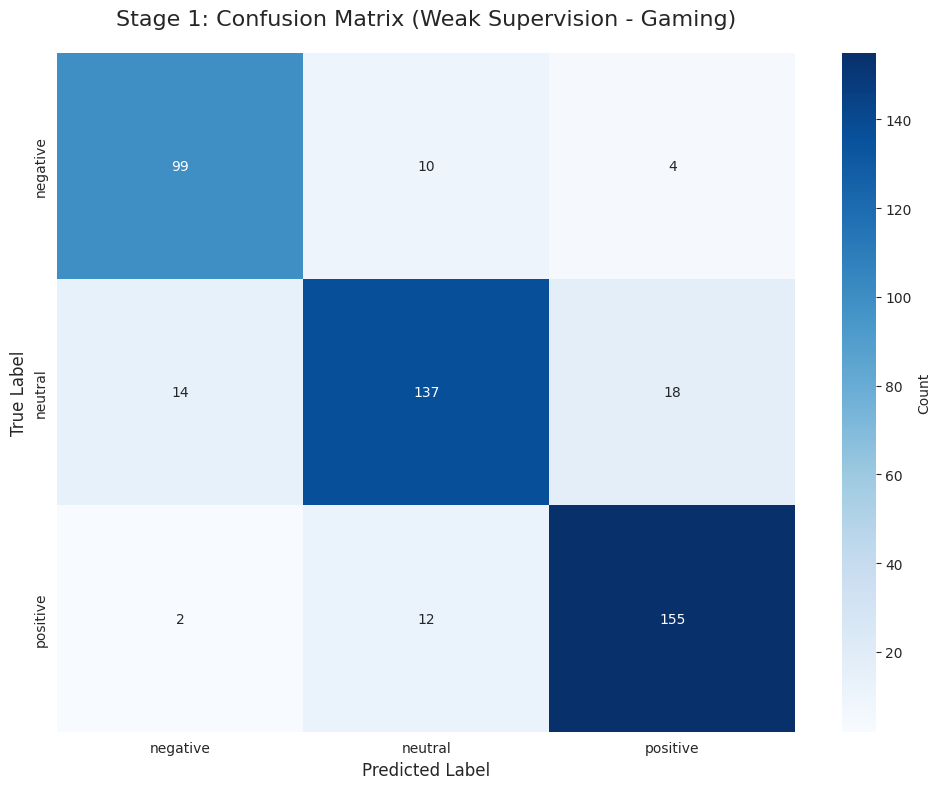


📈 Per-class Accuracy:
   negative  : 0.8761 (87.61%)
   neutral   : 0.8107 (81.07%)
   positive  : 0.9172 (91.72%)

⏱️ Training Time: 1149.50 seconds (19.2 minutes)


In [21]:
# Confusion Matrix
unique_labels = sorted(set(true_labels_test))
cm = confusion_matrix(true_labels_test, finetuned_labels, labels=unique_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=unique_labels,
    yticklabels=unique_labels,
    cbar_kws={'label': 'Count'}
)
plt.title('Stage 1: Confusion Matrix (Weak Supervision - Gaming)', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n📈 Per-class Accuracy:")
for i, label in enumerate(unique_labels):
    class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f"   {label:10s}: {class_acc:.4f} ({class_acc*100:.2f}%)")

# Training time
training_time = train_result.metrics.get('train_runtime', 0)
print(f"\n⏱️ Training Time: {training_time:.2f} seconds ({training_time/60:.1f} minutes)")

## 💾 Stage 5: Save Results for Stage 4 Comparison

In [22]:
# Save results to JSON (compatible with Stage 4 comparison)
results = {
    'stage': 1,
    'method': 'Weak Supervision (Reddit Gaming)',
    'dataset': 'Reddit Gaming Posts',
    'dataset_size': len(gaming_data),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'model': 'cardiffnlp/twitter-roberta-base-sentiment-latest',
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'learning_rate': training_args.learning_rate,
    'metrics': {
        'accuracy': float(accuracy),
        'f1_weighted': float(f1_weighted),
    },
    'weak_labeling': {
        'signals_used': ['awards', 'comments', 'upvote_ratio', 'score', 'gaming_text_features', 'sarcasm'],
        'avg_confidence': float(df_balanced['weak_confidence'].mean()),
        'labeled_samples': len(df_balanced),
        'min_confidence_threshold': 0.6
    },
    'gaming_focus': {
        'subreddits': GAMING_SUBREDDITS,
        'keywords': GAMING_KEYWORDS,
        'subreddits_count': len(GAMING_SUBREDDITS)
    },
    'training_time_seconds': float(training_time)
}

with open('stage1_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("💾 Results saved to: stage1_results.json")
print("   ✅ Compatible with Stage 4 comparison")

💾 Results saved to: stage1_results.json
   ✅ Compatible with Stage 4 comparison


In [23]:
# Save model & tokenizer
model_path = './stage1_roberta_gaming_weak_final'

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"💾 Model saved to: {model_path}")
print("\n✅ Stage 1 complete!")

# Save additional datasets for reference
df_balanced.to_csv('stage1_gaming_weak_labeled_dataset.csv', index=False)
print("💾 Gaming weak labeled dataset saved")

💾 Model saved to: ./stage1_roberta_gaming_weak_final

✅ Stage 1 complete!
💾 Gaming weak labeled dataset saved


## 📥 Stage 6: Download Files (Google Colab)

In [24]:
# Download results if on Colab
try:
    from google.colab import files

    print("📥 Downloading Stage 1 results...")

    files.download('stage1_results.json')
    files.download('stage1_gaming_weak_labeled_dataset.csv')

    print("✅ Stage 1 files downloaded!")

except ImportError:
    print("ℹ️ Not running on Colab - files saved locally")

print("\n" + "="*70)
print("🎉 STAGE 1 COMPLETE!")
print("="*70)

📥 Downloading Stage 1 results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Stage 1 files downloaded!

🎉 STAGE 1 COMPLETE!


In [26]:
# ============================================================
# CROSS-EVALUATION ON KAGGLE DATA (GROUND TRUTH)
# ============================================================
# Mục tiêu: Đánh giá xem model học từ "Weak Label" (Reddit)
# hoạt động tốt thế nào trên dữ liệu chuẩn con người gán nhãn (Kaggle).
# ============================================================

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report
from datasets import Dataset

print("\n" + "="*60)
print("🚀 STARTING CROSS-EVALUATION ON KAGGLE DATASET")
print("="*60)

# 1. Tải dữ liệu Kaggle (Dữ liệu chuẩn của Stage 3)
try:
    df_kaggle = pd.read_csv("cleaned_comments.csv")
    print(f"✅ Loaded Kaggle dataset: {len(df_kaggle)} samples")
except FileNotFoundError:
    print("❌ Error: 'cleaned_comments.csv' not found. Please upload it!")
    # Dừng nếu không có file
    raise

# 2. Tiền xử lý dữ liệu Kaggle (Giống hệt quy trình Stage 3)
# Đổi tên cột cho khớp
if 'sentiment' in df_kaggle.columns:
    df_kaggle = df_kaggle.rename(columns={'sentiment': 'label', 'comment': 'text'})

# Map label sang số (negative=0, neutral=1, positive=2)
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
# Chỉ lấy các dòng có label hợp lệ
df_kaggle = df_kaggle[df_kaggle['label'].isin(label2id.keys())].copy()
df_kaggle['label_id'] = df_kaggle['label'].map(label2id)

# Xử lý text (fillna)
df_kaggle['text'] = df_kaggle['text'].fillna("").astype(str)

# Chia tập test (Lấy 20% làm tập test để đánh giá - hoặc dùng toàn bộ nếu muốn)
# Ở đây ta dùng toàn bộ để đánh giá tổng quát
kaggle_dataset = Dataset.from_pandas(df_kaggle[['text', 'label_id']].rename(columns={'label_id': 'label'}))

# 3. Tokenize dữ liệu Kaggle bằng Tokenizer của Stage 1
print("🔤 Tokenizing Kaggle dataset...")
kaggle_encoded = kaggle_dataset.map(tokenize_function, batched=True)

# 4. Dự đoán bằng Model Stage 1
print("🔮 Predicting on Kaggle Ground Truth data...")
predictions = trainer.predict(kaggle_encoded)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = kaggle_encoded['label']

# 5. Tính toán Metrics thực tế
real_acc = accuracy_score(true_labels, preds)
real_f1 = f1_score(true_labels, preds, average='weighted')

print("\n" + "="*60)
print("📊 REAL-WORLD PERFORMANCE (Stage 1 Model vs Human Labels)")
print("="*60)
print(f"   Real Accuracy: {real_acc:.4f} ({real_acc*100:.2f}%)")
print(f"   Real F1-Score: {real_f1:.4f}")
print("\n📋 Per-class Performance on Kaggle Data:")
print(classification_report(true_labels, preds, target_names=['negative', 'neutral', 'positive'], digits=4))

# 6. Lưu kết quả so sánh vào file JSON riêng
comparison_results = {
    'stage': '1_cross_eval',
    'eval_dataset': 'Kaggle (Human Labeled)',
    'model_source': 'Stage 1 (Weak Supervision)',
    'real_accuracy': float(real_acc),
    'real_f1_weighted': float(real_f1),
    'note': 'This metric shows how well Weak Supervision generalizes to human-labeled data'
}

with open('stage1_cross_eval_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

print("💾 Cross-evaluation results saved to 'stage1_cross_eval_results.json'")


🚀 STARTING CROSS-EVALUATION ON KAGGLE DATASET
✅ Loaded Kaggle dataset: 21821 samples
🔤 Tokenizing Kaggle dataset...


Map:   0%|          | 0/21821 [00:00<?, ? examples/s]

🔮 Predicting on Kaggle Ground Truth data...



📊 REAL-WORLD PERFORMANCE (Stage 1 Model vs Human Labels)
   Real Accuracy: 0.4788 (47.88%)
   Real F1-Score: 0.4401

📋 Per-class Performance on Kaggle Data:
              precision    recall  f1-score   support

    negative     0.6696    0.0382    0.0723      4031
     neutral     0.4357    0.5504    0.4864      8013
    positive     0.5130    0.6018    0.5539      9777

    accuracy                         0.4788     21821
   macro avg     0.5394    0.3968    0.3708     21821
weighted avg     0.5135    0.4788    0.4401     21821

💾 Cross-evaluation results saved to 'stage1_cross_eval_results.json'


---

# 🎯 **STAGE 1 SUMMARY**

## ✅ **What We Did:**

1. **Gaming Data Collection:** Scraped Reddit gaming posts from 6 specialized subreddits
2. **Optimized Weak Supervision:** 8-signal approach with gaming-specific optimizations
3. **Model Training:** Fine-tuned RoBERTa on gaming weak labels
4. **Evaluation:** Comprehensive metrics matching Stage 2-3 format
5. **Results Export:** Generated `stage1_results.json` for Stage 4 comparison

## 🎮 **Gaming Focus Innovation:**

**Gaming Subreddits:**
- ✅ r/gaming, r/Games, r/pcgaming
- ✅ r/gamernews, r/gamedev, r/indiegaming

**Gaming Keywords:**
- ✅ game, gaming, gameplay, review, experience

